# Build a Financial Analyst ReAct Agentic AI System with LangChain

### Building a Financial Analyst ReAct Agentic AI System

In this project, we will design a **Financial Analyst ReAct Agentic AI System** to assist investors by providing accurate and up-to-date stock market insights. This system will leverage the `create_agent` function from **LangChain**, a more robust and modern alternative to the deprecated LangChain version. The workflow comprises the following components:

1. **Agent System Prompt**: The agent is designed to:
   - Validate input queries to ensure they are relevant and specific.
   - Provide detailed market analysis or individual stock insights depending on the user's query.
   - For invalid queries, respond professionally and guide the user appropriately.
   - Deliver concise, accurate, and professional responses while emphasizing data accuracy.

   **Flows**:
   - **Flow 1**: For general market queries, use tools to analyze trends and suggest stock opportunities.
   - **Flow 2**: For stock-specific queries, validate the ticker, retrieve data, and provide insights.

2. **Financial Analysis Tools**: The system utilizes the following tools to interact with stock market data:
   - **GET_STOCK_TICKER**: Validates and fetches stock tickers based on user queries.
   - **GET_STOCK_PRICE_METRICS**: Retrieves price trends and metrics for specific stocks.
   - **GET_STOCK_NEWS**: Extracts recent news articles related to stocks or markets.
   - **GET_STOCK_FUNDAMENTAL_INDICATOR_METRICS**: Provides insights into financial indicators like P/E ratio, ROE, etc.
   - **GET_GENERAL_MARKET_DATA**: Fetches general market trends and data.

3. **Stock Market Data Providers**: The system integrates with leading data providers such as Yahoo Finance, Finviz, Cboe, and others through platforms like __OpenBB__ to ensure reliable and real-time information.

4. **ReAct Reasoning Framework**: The agent employs ReAct reasoning to combine logical deduction with dynamic tool usage, ensuring precise and actionable results.

5. **Final Response**: After processing the data, the agent delivers a well-structured response emphasizing clarity and encouraging users to verify any investment decisions.

By utilizing LangChain's `create_agent` and integrating comprehensive financial data tools, this system empowers investors with actionable insights, enabling informed decision-making in the dynamic stock market environment.

![](https://i.imgur.com/ZbYjVIE.png)

In [1]:
from openbb import obb

# Along with the installed providers' credentials, if an entry in the .env file ends with _API_KEY, it will be accessible.
obb.user.credentials

Credentials

alpha_vantage_api_key: None
benzinga_api_key: None
biztoc_api_key: None
bls_api_key: None
cftc_app_token: None
congress_gov_api_key: None
econdb_api_key: None
eia_api_key: None
eleven_api_key: **********
fmp_api_key: **********
fred_api_key: None
gemini_api_key: **********
google_api_key: **********
groq_api_key: **********
intrinio_api_key: None
nasdaq_api_key: None
openai_api_key: **********
openbb_api_key: **********
polygon_api_key: None
serper_api_key: **********
tavily_api_key: **********
tiingo_token: None
tradier_account_type: None
tradier_api_key: None
tradingeconomics_api_key: None
weather_api_key: **********
yfinance_api_key: **********

## Create Financial Data Retrieval Tools

We will create custom tools as following which can be used by our Agentic AI System to interact with stock market data:

   - **GET_STOCK_TICKER**: Validates and fetches stock tickers based on user queries.
   - **GET_STOCK_PRICE_METRICS**: Retrieves price trends and metrics for specific stocks.
   - **GET_STOCK_NEWS**: Extracts recent news articles related to stocks or markets.
   - **GET_STOCK_FUNDAMENTAL_INDICATOR_METRICS**: Provides insights into financial indicators like P/E ratio, ROE, etc.
   - **GET_GENERAL_MARKET_DATA**: Fetches general market trends and data.

   
![](https://i.imgur.com/C9Ay1kv.png)

Refer to the comprehensive [OpenBB Documentation](https://docs.openbb.co/platform/reference) for understanding the specific functions used below in more detail.

In [18]:
from openbb import obb
from langchain_core.tools import tool
from datetime import datetime, timedelta

@tool
def get_stock_ticker_symbol(stock_name: str) -> str:
    """Get the symbol, name and CIK for any publicly traded company"""
    # Use OpenBB to search for stock ticker symbol and company details by name.
    # The provider "sec" fetches data from the U.S. Securities and Exchange Commission (SEC).
    res = obb.equity.search(stock_name, provider="sec")

    # Convert the result to a DataFrame and format it as markdown for readability.
    stock_ticker_details = res.to_df().to_markdown()

    # Prepare the output with the stock details.
    output = """Here are the details of the company and its stock ticker symbol:\n\n""" + stock_ticker_details
    return output

@tool
def get_stock_price_metrics(stock_ticker: str) -> str:
    """Get historical stock price data, stock price quote and price performance data
       like price changes for a specific stock ticker"""

    # Fetch the latest stock price quote using "cboe" provider.
    res = obb.equity.price.quote(stock_ticker, provider='cboe')
    price_quote = res.to_df().to_markdown()

    # Retrieve stock price performance metrics (e.g., percentage change) using "finviz" provider.
    res = obb.equity.price.performance(symbol=stock_ticker, provider='finviz')
    price_performance = res.to_df().to_markdown()

    # Fetch historical price data for the past year using "yfinance" provider.
    end_date = datetime.now()
    start_date = (end_date - timedelta(days=365)).strftime("%Y-%m-%d")
    res = obb.equity.price.historical(symbol=stock_ticker, start_date=start_date,
                                      interval='1d', provider='yfinance')
    price_historical = res.to_df().to_markdown()

    # Combine the results into a formatted output.
    output = ("""Here are the stock price metrics and data for the stock ticker symbol """ + stock_ticker + """: \n\n""" +
              "Price Quote Metrics:\n\n" + price_quote +
              "\n\nPrice Performance Metrics:\n\n" + price_performance +
              "\n\nPrice Historical Data:\n\n" + price_historical)
    return output

@tool
def get_stock_news(stock_ticker: str) -> str:
    """Get news article headlines for a specific stock ticker"""

    # Define the date range to fetch news (last 45 days).
    end_date = datetime.now()
    start_date = (end_date - timedelta(days=45)).strftime("%Y-%m-%d")

    # Retrieve news headlines for the stock using "tmx" provider.
    res = obb.news.company(symbol=stock_ticker, start_date=start_date, provider='yfinance', limit=50)
    news = res.to_df()
    
    # Extract relevant columns (symbols and titles) and format as markdown.
    news = news[['symbol', 'title']].to_markdown()

    # Prepare the output with the news headlines.
    output = ("""Here are the recent news headlines for the stock ticker symbol """ + stock_ticker + """: \n\n""" + news)
    return output

@tool
def get_stock_fundamental_indicator_metrics(stock_ticker: str) -> str:
    """Get fundamental indicator metrics for a specific stock ticker"""

    # Retrieve fundamental financial ratios (e.g., P/E ratio, ROE) using "fmp" provider.
    res = obb.equity.fundamental.ratios(symbol=stock_ticker, period='annual',
                                        limit=10, provider='fmp')
    fundamental_ratios = res.to_df().to_markdown()

    # Fetch additional fundamental metrics (e.g., EBITDA, revenue growth) using "yfinance" provider.
    res = obb.equity.fundamental.metrics(symbol=stock_ticker, period='annual',
                                        limit=10, provider='yfinance')
    fundamental_metrics = res.to_df().to_markdown()

    # Combine fundamental ratios and metrics into a single output.
    output = ("""Here are the fundamental indicator metrics and data for the stock ticker symbol """ + stock_ticker + """: \n\n""" +
              "Fundamental Ratios:\n\n" + fundamental_ratios +
              "\n\nFundamental Metrics:\n\n" + fundamental_metrics)
    return output

@tool
def get_general_market_data() -> str:
    """Get general data and indicators for the whole stock market including,
       most actively traded stocks based on volume, top price gainers and top price losers.
       Useful when you want an overview of the market and what stocks to look at."""

    # Retrieve the most actively traded stocks using "yfinance" provider.
    res = obb.equity.discovery.active(sort='desc', provider='yfinance', limit=15)
    most_active_stocks = res.to_df().to_markdown()

    # Fetch the top price gainers using "yfinance" provider.
    res = obb.equity.discovery.gainers(sort='desc', provider='yfinance', limit=15)
    price_gainers = res.to_df().to_markdown()

    # Retrieve the top price losers using "yfinance" provider.
    res = obb.equity.discovery.losers(sort='desc', provider='yfinance', limit=15)
    price_losers = res.to_df().to_markdown()

    # Combine the market data into a single formatted output.
    output = ("""Here's some detailed information of the stock market which includes most actively traded stocks, gainers and losers:\n\n""" +
              "Most actively traded stocks:\n\n" + most_active_stocks +
              "\n\nTop price gainers:\n\n" + price_gainers +
              "\n\nTop price losers:\n\n" + price_losers)
    return output

## Test Tools

In [3]:
from IPython.display import display, Markdown

response = get_general_market_data.invoke({})
display(Markdown(response))

Here's some detailed information of the stock market which includes most actively traded stocks, gainers and losers:

Most actively traded stocks:

|    | symbol   | name                          |   price |     change |   percent_change |    volume |    open |     high |      low |   previous_close |     ma50 |     ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date             | currency   |
|---:|:---------|:------------------------------|--------:|-----------:|-----------------:|----------:|--------:|---------:|---------:|-----------------:|---------:|----------:|------------:|-----------:|-------------:|---------------------:|-------------:|----------------:|----------:|--------------:|-------------:|-----------------:|:-----------|:--------------------|:--------------------------|:-----------|
|  0 | NVDA     | NVIDIA Corporation            |  188.12 | -0.730011  |      -0.00386556 | 178569651 | 191.715 | 193.63   | 186.15   |           188.85 | 186.511  | 160.495   |    212.19   |     86.62  |  4.58016e+12 |          2.4305e+10  |        4.892 |        38.4546  |      4.04 |       7.56636 |     24.8627  |      0.000211808 | NMS        | America/New_York    | 2026-02-25 16:00:00-05:00 | USD        |
|  1 | INTC     | Intel Corporation             |   39.37 | -0.0100021 |      -0.00025399 |  95677780 |  41.59  |  42.1    |  39.27   |            39.38 |  38.0094 |  27.5222  |     44.02   |     17.67  |  1.87795e+11 |          4.77e+09    |       22.32  |         1.76389 |      0.06 |       0.59549 |     66.1136  |      0           | NMS        | America/New_York    | 2025-10-23 16:00:00-04:00 | USD        |
|  2 | SOFI     | SoFi Technologies, Inc.       |   29.28 |  1.82      |       0.0662783  |  73582442 |  27.825 |  29.86   |  27.6    |            27.46 |  28.0624 |  21.3071  |     32.73   |      8.6   |  3.69059e+10 |          1.26045e+09 |        7.289 |         4.01701 |      0.56 |       0.57295 |     51.1039  |      0           | NMS        | America/New_York    | 2026-01-30 08:30:00-05:00 | USD        |
|  3 | BBAI     | BigBear.ai, Inc.              |    5.88 |  0.04      |       0.00684931 |  73385785 |   5.87  |   5.945  |   5.56   |             5.84 |   6.1892 |   5.4297  |     10.36   |      2.36  |  2.56692e+09 |          4.36551e+08 |        1.4   |         4.2     |     -1.45 |      -0.2     |    -29.4     |      0           | NYQ        | America/New_York    | 2025-11-10 16:00:00-05:00 | USD        |
|  4 | NU       | Nu Holdings Ltd.              |   17.94 |  0.92      |       0.0540541  |  67861646 |  17.18  |  18.1368 |  17.165  |            17.02 |  16.361  |  13.9068  |     18.1368 |      9.01  |  8.69296e+10 |          3.82298e+09 |        2.178 |         8.23691 |      0.52 |       0.91174 |     19.6767  |      0           | NYQ        | America/New_York    | 2026-02-25 16:00:00-05:00 | USD        |
|  5 | SMR      | NuScale Power Corporation     |   18.78 |  2.47      |       0.151441   |  67835272 |  17.945 |  19.55   |  17.34   |            16.31 |  24.2524 |  30.5387  |     57.42   |     11.08  |  5.3118e+09  |          2.82843e+08 |        4.945 |         3.79778 |     -2.14 |      -0.55775 |    -33.671   |      0           | NYQ        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |
|  6 | TSLA     | Tesla, Inc.                   |  451.67 | 13.6       |       0.0310453  |  67251801 | 447.72  | 457.55   | 444.57   |           438.07 | 445.012  | 360.201   |    498.83   |    214.25  |  1.50217e+12 |          3.32582e+09 |       24.058 |        18.7742  |      1.45 |       2.20383 |    204.948   |      0           | NMS        | America/New_York    | 2026-01-28 16:00:00-05:00 | USD        |
|  7 | SLB      | SLB Limited                   |   43.8  |  3.6       |       0.0895522  |  56247010 |  43     |  45.155  |  42.52   |            40.2  |  37.1806 |  35.5665  |     45.155  |     31.11  |  6.54338e+10 |          1.49392e+09 |       17.16  |         2.55245 |      2.57 |       2.94967 |     14.8491  |      0.0281095   | NYQ        | America/New_York    | 2026-01-23 08:30:00-05:00 | USD        |
|  8 | AAL      | American Airlines Group, Inc. |   15.83 |  0.35      |       0.0226098  |  55344789 |  15.43  |  16.0268 |  15.41   |            15.48 |  14.0292 |  12.1611  |     19.1    |      8.5   |  1.04492e+10 |          6.60086e+08 |       -6.002 |        -2.63745 |      0.87 |       1.86063 |      8.50787 |      0           | NMS        | America/New_York    | 2025-10-23 08:30:00-04:00 | USD        |
|  9 | ACHR     | Archer Aviation Inc.          |    8.56 |  0.43      |       0.0528906  |  53800281 |   8.25  |   8.82   |   8.18   |             8.13 |   8.6064 |   9.48695 |     14.62   |      5.48  |  6.28398e+09 |          7.34109e+08 |        2.54  |         3.37008 |     -1.17 |      -0.73488 |    -11.6482  |      0           | NYQ        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |
| 10 | OPEN     | Opendoor Technologies Inc     |    6.32 |  0.25      |       0.0411862  |  52696874 |   6.07  |   6.33   |   5.992  |             6.07 |   7.1064 |   3.99102 |     10.87   |      0.508 |  6.02794e+09 |          9.53788e+08 |        1.051 |         6.01332 |     -0.44 |      -0.21282 |    -29.6965  |      0           | NMS        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |
| 11 | PFE      | Pfizer, Inc.                  |   25.17 | -0.0100002 |      -0.00039715 |  52336988 |  25.2   |  25.4    |  24.95   |            25.18 |  25.1424 |  24.479   |     27.69   |     20.92  |  1.43109e+11 |          5.68571e+09 |       16.321 |         1.54218 |      1.72 |       2.99568 |      8.4021  |      0.0675139   | NYQ        | America/New_York    | 2026-02-03 08:30:00-05:00 | USD        |
| 12 | F        | Ford Motor Company            |   13.47 |  0.13      |       0.00974514 |  49292204 |  13.25  |  13.48   |  13.2001 |            13.34 |  13.178  |  11.4898  |     13.99   |      8.44  |  5.36712e+10 |          3.91365e+09 |       11.894 |         1.1325  |      1.17 |       1.4799  |      9.10197 |      0.0449775   | NYQ        | America/New_York    | 2026-02-10 16:00:00-05:00 | USD        |
| 13 | T        | AT&T Inc.                     |   24.71 |  0.15      |       0.00610748 |  48578378 |  24.405 |  24.75   |  24.37   |            24.56 |  25.0088 |  27.0898  |     29.79   |     21.38  |  1.76686e+11 |          7.08945e+09 |       15.573 |         1.58672 |      3.07 |       2.23177 |     11.0719  |      0.0451954   | NYQ        | America/New_York    | 2026-01-28 08:30:00-05:00 | USD        |
| 14 | AMZN     | Amazon.com, Inc.              |  233.06 |  6.56      |       0.0289625  |  45804714 | 228.865 | 234      | 227.18   |           226.5  | 231.526  | 217.029   |    258.6    |    161.38  |  2.49146e+12 |          1.06902e+10 |       34.587 |         6.73837 |      7.09 |       7.84506 |     29.7079  |      0           | NMS        | America/New_York    | 2025-10-30 16:00:00-04:00 | USD        |

Top price gainers:

|    | symbol   | name                            |   price |   change |   percent_change |   volume |     open |     high |      low |   previous_close |     ma50 |     ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date             | currency   |
|---:|:---------|:--------------------------------|--------:|---------:|-----------------:|---------:|---------:|---------:|---------:|-----------------:|---------:|----------:|------------:|-----------:|-------------:|---------------------:|-------------:|----------------:|----------:|--------------:|-------------:|-----------------:|:-----------|:--------------------|:--------------------------|:-----------|
|  0 | FIGR     | Figure Technology Solutions, In |   53.22 |     9.48 |         0.216735 |  7057487 |  44.91   |  53.53   |  44.7    |            43.74 |  39.3017 |  39.8427  |       53.53 |     30.01  |  1.13887e+10 |          1.76101e+08 |        5.489 |         9.69576 |      0.27 |       0.965   |     55.1503  |       0          | NMS        | America/New_York    | 2025-11-13 16:00:00-05:00 | USD        |
|  1 | QXO      | QXO, Inc.                       |   23.3  |     3.58 |         0.181542 | 25185506 |  20.47   |  23.795  |  20.41   |            19.72 |  19.1188 |  18.5554  |       24.69 |     11.85  |  1.57169e+10 |          6.74547e+08 |       12.999 |         1.79245 |     -0.47 |       0.43183 |     53.9564  |       0          | NYQ        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |
|  2 | AVAV     | AeroVironment, Inc.             |  297.41 |    41.22 |         0.160896 |  2339493 | 268.758  | 302.42   | 268      |           256.19 | 292.963  | 242.769   |      417.86 |    102.25  |  1.48503e+10 |          4.99259e+07 |       88.885 |         3.34601 |     -1.22 |       4.61333 |     64.4675  |       0          | NMS        | America/New_York    | 2025-12-09 16:00:00-05:00 | USD        |
|  3 | SMR      | NuScale Power Corporation       |   18.78 |     2.47 |         0.151441 | 67835272 |  17.945  |  19.55   |  17.34   |            16.31 |  24.2524 |  30.5387  |       57.42 |     11.08  |  5.3118e+09  |          2.82843e+08 |        4.945 |         3.79778 |     -2.14 |      -0.55775 |    -33.671   |       0          | NYQ        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |
|  4 | OKLO     | Oklo Inc.                       |   89.34 |    11.54 |         0.148329 | 18072829 |  81.65   |  90.81   |  80.4    |            77.8  | 100.189  |  74.2737  |      193.84 |     17.42  |  1.39591e+10 |          1.56247e+08 |        7.719 |        11.574   |     -0.56 |      -0.62537 |   -142.859   |       0          | NYQ        | America/New_York    | 2025-11-11 16:00:00-05:00 | USD        |
|  5 | FTK      | Flotek Industries, Inc.         |   19.54 |     2.49 |         0.146041 |   867453 |  17.43   |  20.09   |  17.52   |            17.05 |  15.9376 |  13.1755  |       20.09 |      6.05  |  5.8733e+08  |          3.00578e+07 |        3.703 |         5.2768  |      0.92 |       0.86    |     22.7209  |       0          | NYQ        | America/New_York    | 2025-11-04 16:00:00-05:00 | USD        |
|  6 | VICR     | Vicor Corporation               |  133.64 |    16.78 |         0.143591 |  2093901 | 123.7    | 149.99   | 123      |           116.86 |  95.089  |  59.5804  |      149.99 |     38.92  |  6.00301e+09 |          3.29259e+07 |       14.105 |         9.47465 |      1.82 |       2.15667 |     61.9659  |       0          | NMS        | America/New_York    | 2025-10-21 16:00:00-04:00 | USD        |
|  7 | RDW      | Redwire Corporation             |   10.26 |     1.23 |         0.136213 | 28034292 |   9.204  |  10.565  |   9.05   |             9.03 |   6.753  |  10.6514  |       26.66 |      4.87  |  1.69445e+09 |          1.65151e+08 |        5.98  |         1.71572 |     -3.11 |      -0.38    |    -27       |       0          | NYQ        | America/New_York    | 2025-11-05 16:00:00-05:00 | USD        |
|  8 | HUT      | Hut 8 Corp.                     |   58.25 |     6.98 |         0.136142 |  9811367 |  53.06   |  59.76   |  52.75   |            51.27 |  43.8398 |  27.6956  |       59.76 |     10.04  |  6.29313e+09 |          1.08037e+08 |       13.565 |         4.29414 |      1.94 |      -0.65    |    -89.6154  |       0          | NMS        | America/New_York    | 2025-11-04 08:30:00-05:00 | USD        |
|  9 | KTOS     | Kratos Defense & Security Solut |   89.93 |    10.64 |         0.134191 |  4356105 |  84.913  |  90.11   |  82.1301 |            79.29 |  78.0138 |  59.7315  |      112.57 |     23.9   |  1.51838e+10 |          1.68841e+08 |       11.736 |         7.66275 |      0.13 |       0.75701 |    118.796   |       0          | NMS        | America/New_York    | 2025-11-04 16:00:00-05:00 | USD        |
| 10 | IREN     | IREN LIMITED                    |   48.24 |     5.54 |         0.129742 | 46237083 |  44.8525 |  48.29   |  44.17   |            42.7  |  49.1574 |  27.3203  |       76.87 |      5.125 |  1.58392e+10 |          3.28342e+08 |       10.168 |         4.7443  |      1.74 |       0.83677 |     57.6503  |       0          | NMS        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |
| 11 | AMKR     | Amkor Technology, Inc.          |   48.13 |     5.21 |         0.121389 |  7931380 |  45.93   |  48.41   |  45.452  |            42.92 |  37.2656 |  25.8843  |       48.41 |     14.03  |  1.18974e+10 |          2.47193e+08 |       17.429 |         2.76149 |      1.24 |       1.68708 |     28.5286  |       0.00771202 | NMS        | America/New_York    | 2025-10-27 16:00:00-04:00 | USD        |
| 12 | CIFR     | Cipher Mining Inc.              |   18.16 |     1.96 |         0.120988 | 26580186 |  16.87   |  18.2955 |  16.64   |            16.2  |  17.6697 |   9.2718  |       25.52 |      1.86  |  7.17487e+09 |          3.95092e+08 |        1.99  |         9.12563 |     -0.17 |       0.49    |     37.0612  |       0          | NMS        | America/New_York    | 2025-11-03 08:30:00-05:00 | USD        |
| 13 | JOBY     | Joby Aviation, Inc.             |   16.04 |     1.68 |         0.116992 | 36689731 |  14.61   |  16.38   |  14.45   |            14.36 |  14.7472 |  12.3767  |       20.95 |      4.96  |  1.4625e+10  |          9.11783e+08 |        1.025 |        15.6488  |     -1.35 |      -0.76033 |    -21.0961  |       0          | NYQ        | America/New_York    | 2025-11-05 16:00:00-05:00 | USD        |
| 14 | ANNX     | Annexon, Inc.                   |    5.22 |     0.53 |         0.113006 |  5408445 |   4.74   |   5.23   |   4.55   |             4.69 |   4.052  |   2.76895 |        5.48 |      1.285 |  7.78072e+08 |          1.49056e+08 |        1.402 |         3.72325 |     -1.41 |      -1.19058 |     -4.38442 |       0          | NMS        | America/New_York    | nan                       | USD        |

Top price losers:

|    | symbol   | name                           |   price |    change |   percent_change |   volume |   open |    high |      low |   previous_close |     ma50 |    ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date             | currency   |
|---:|:---------|:-------------------------------|--------:|----------:|-----------------:|---------:|-------:|--------:|---------:|-----------------:|---------:|---------:|------------:|-----------:|-------------:|---------------------:|-------------:|----------------:|----------:|--------------:|-------------:|-----------------:|:-----------|:--------------------|:--------------------------|:-----------|
|  0 | PRKS     | United Parks & Resorts Inc.    |   35.18 | -1.04     |       -0.0287134 |   680237 |  35.95 |  36.83  |  35.17   |            36.22 |  37.99   |  45.6212 |       59.24 |     29.62  |  1.93577e+09 |          5.45506e+07 |       -5.616 |       -6.26424  |      3.31 |       3.84734 |      9.14398 |       0          | NYQ        | America/New_York    | 2025-11-06 08:30:00-05:00 | USD        |
|  1 | ROIV     | Roivant Sciences Ltd.          |   21.3  | -0.630001 |       -0.0287278 |  5952528 |  21.87 |  21.99  |  20.7809 |            21.93 |  20.7312 |  14.2225 |       23.47 |      8.73  |  1.4814e+10  |          6.95492e+08 |        6.325 |        3.36759  |     -0.99 |      -1.13265 |    -18.8055  |       0          | NMS        | America/New_York    | 2025-11-10 08:30:00-05:00 | USD        |
|  2 | SMCI     | Super Micro Computer, Inc.     |   30.07 | -0.889999 |       -0.0287468 | 36443229 |  31.59 |  32.03  |  29.98   |            30.96 |  37.0446 |  42.2777 |       66.44 |     25.71  |  1.79509e+10 |          5.96971e+08 |       10.93  |        2.75114  |      1.27 |       3.04361 |      9.87971 |       0          | NMS        | America/New_York    | 2025-11-04 16:00:00-05:00 | USD        |
|  3 | NUVL     | Nuvalent, Inc.                 |   97.94 | -2.89999  |       -0.0287584 |   783506 | 100.31 | 103.365 |  95.505  |           100.84 | 101.81   |  83.425  |      112.88 |     55.535 |  7.60575e+09 |          7.2222e+07  |       11.697 |        8.37309  |     -5.33 |      -5.60307 |    -17.4797  |       0          | NMS        | America/New_York    | 2025-10-30 08:30:00-04:00 | USD        |
|  4 | KVUE     | Kenvue Inc.                    |   16.82 | -0.5      |       -0.0288684 | 47207999 |  17.22 |  17.245 |  16.78   |            17.32 |  16.5368 |  19.9581 |       25.17 |     14.02  |  3.22255e+10 |          1.9159e+09  |        5.551 |        3.03008  |      0.75 |       1.10654 |     15.2005  |       0.0475173  | NYQ        | America/New_York    | 2025-11-03 08:30:00-05:00 | USD        |
|  5 | KGS      | Kodiak Gas Services, Inc.      |   36.54 | -1.1      |       -0.0292242 |  1520005 |  38.32 |  38.54  |  36.35   |            37.64 |  35.5946 |  34.743  |       50.43 |     29.25  |  3.13089e+09 |          8.56839e+07 |       14.413 |        2.53521  |      0.84 |       2.34739 |     15.5662  |       0.0478215  | NYQ        | America/New_York    | 2025-11-04 16:00:00-05:00 | USD        |
|  6 | CTRA     | Coterra Energy Inc.            |   25.82 | -0.780001 |       -0.0293233 |  8305753 |  26.5  |  26.69  |  24.98   |            26.6  |  25.7636 |  25.0767 |       29.95 |     22.33  |  1.97043e+10 |          7.61378e+08 |       19.264 |        1.34032  |      2.16 |       2.49608 |     10.3442  |       0.0327068  | NYQ        | America/New_York    | 2025-11-03 16:00:00-05:00 | USD        |
|  7 | MGY      | Magnolia Oil & Gas Corporation |   21.82 | -0.66     |       -0.0293594 |  1828516 |  22.74 |  22.93  |  21.3    |            22.48 |  22.557  |  23.0217 |       26.84 |     19.09  |  4.16357e+09 |          1.83153e+08 |       10.613 |        2.05597  |      1.8  |       1.73777 |     12.5563  |       0.0266904  | NYQ        | America/New_York    | 2025-10-29 16:00:00-04:00 | USD        |
|  8 | CLF      | Cleveland-Cliffs Inc.          |   13.2  | -0.400001 |       -0.0294118 | 12641367 |  13.79 |  13.95  |  13.185  |            13.6  |  12.3788 |  10.1898 |       16.7  |      5.63  |  7.52014e+09 |          5.69707e+08 |       11.049 |        1.19468  |     -3.4  |       0.22157 |     59.5749  |       0          | NYQ        | America/New_York    | 2025-10-20 08:30:00-04:00 | USD        |
|  9 | GIS      | General Mills, Inc.            |   44.37 | -1.35     |       -0.0295276 | 10099114 |  45.54 |  45.565 |  44.35   |            45.72 |  46.9722 |  51.2361 |       67.35 |     44.35  |  2.3675e+10  |          5.33582e+08 |       17.46  |        2.54124  |      4.65 |       3.74061 |     11.8617  |       0.0529309  | NYQ        | America/New_York    | 2025-12-17 08:30:00-05:00 | USD        |
| 10 | CDNS     | Cadence Design Systems, Inc.   |  301.22 | -9.17999  |       -0.0295747 |  3884722 | 311.24 | 314.17  | 300.4    |           310.4  | 322.555  | 317.96   |      376.45 |    221.56  |  8.20794e+10 |          2.72201e+08 |       19.1   |       15.7707   |      3.89 |       8.05257 |     37.4067  |       0          | NMS        | America/New_York    | 2025-10-27 16:00:00-04:00 | USD        |
| 11 | SBR      | Sabine Royalty Trust           |   68.12 | -2.07999  |       -0.0296295 |    43499 |  69.9  |  70     |  68.22   |            70.2  |  73.1184 |  69.8262 |       84.39 |     58.25  |  9.93145e+08 |          1.45793e+07 |        0.517 |      131.76     |      5.43 |     nan       |    nan       |       0.078547   | NYQ        | America/New_York    | nan                       | USD        |
| 12 | DELL     | Dell Technologies Inc.         |  124.01 | -3.79     |       -0.0296557 |  8390840 | 129.56 | 131.19  | 122.09   |           127.8  | 137.673  | 123.273  |      168.08 |     66.25  |  8.31115e+10 |          3.33918e+08 |       -3.928 |      -31.5708   |      7.48 |      11.4601  |     10.8211  |       0.0158059  | NYQ        | America/New_York    | 2025-11-25 16:00:00-05:00 | USD        |
| 13 | VG       | Venture Global, Inc.           |    6.83 | -0.21     |       -0.0298295 | 13416065 |   7.22 |   7.22  |   6.7631 |             7.04 |   7.4344 |  11.3456 |       24    |      5.72  |  1.67206e+10 |          4.79506e+08 |        2.327 |        2.93511  |      0.87 |       0.8164  |      8.366   |       0.00710227 | NYQ        | America/New_York    | 2025-11-10 08:30:00-05:00 | USD        |
| 14 | CIVI     | Civitas Resources, Inc.        |   26.96 | -0.830002 |       -0.0298669 |  1080989 |  28.4  |  28.58  |  26.07   |            27.79 |  28.2374 |  30.2181 |       55.35 |     22.79  |  2.30005e+09 |          8.53134e+07 |       78.377 |        0.343978 |      6.89 |       4.81036 |      5.60457 |       0.0719683  | NYQ        | America/New_York    | 2025-11-06 16:00:00-05:00 | USD        |

In [4]:
from IPython.display import display, Markdown

response = get_stock_ticker_symbol.invoke('Nvidia')
display(Markdown(response))

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name        |     cik |
|---:|:---------|:------------|--------:|
|  0 | NVDA     | NVIDIA CORP | 1045810 |

In [6]:
response = get_stock_price_metrics.invoke('NVDA')
display(Markdown(response))

Here are the stock price metrics and data for the stock ticker symbol NVDA: 

Price Quote Metrics:

|    | symbol   | asset_type   | name                   |    bid |   bid_size |   ask |   ask_size |   last_price | last_tick   | last_timestamp      |   open |   high |    low |   close |    volume |   prev_close |   change |   change_percent |   year_high |   year_low |    iv30 |   iv30_annual_high |   hv30_annual_high |   iv30_annual_low |   hv30_annual_low |   iv60_annual_high |   hv60_annual_high |   iv60_annual_low |   hv60_annual_low |   iv90_annual_high |   hv90_annual_high |   iv90_annual_low |   hv90_annual_low |
|---:|:---------|:-------------|:-----------------------|-------:|-----------:|------:|-----------:|-------------:|:------------|:--------------------|-------:|-------:|-------:|--------:|----------:|-------------:|---------:|-----------------:|------------:|-----------:|--------:|-------------------:|-------------------:|------------------:|------------------:|-------------------:|-------------------:|------------------:|------------------:|-------------------:|-------------------:|------------------:|------------------:|
|  0 | NVDA     | stock        | NVIDIA CORPORATION COM | 187.99 |       1400 |   188 |        500 |       187.99 | down        | 2026-01-05 15:59:59 | 191.77 | 193.63 | 186.15 |  188.12 | 183529733 |       188.12 |    -0.73 |        -0.003881 |      212.19 |      86.62 | 0.38509 |            0.74664 |           0.842074 |             0.314 |          0.234918 |            0.67906 |           0.802689 |           0.35329 |          0.246877 |            0.63064 |           0.717722 |           0.36481 |          0.268337 |

Price Performance Metrics:

|    | symbol   |   one_day |   one_week |   one_month |   three_month |   six_month |    ytd |   one_year |   volatility_week |   volatility_month |   price |      volume |   average_volume |   relative_volume | Perf 3Y   | Perf 5Y   | Perf 10Y   |
|---:|:---------|----------:|-----------:|------------:|--------------:|------------:|-------:|-----------:|------------------:|-------------------:|--------:|------------:|-----------------:|------------------:|:----------|:----------|:-----------|
|  0 | NVDA     |   -0.0039 |    -0.0126 |      0.0475 |        0.0027 |      0.1888 | 0.0087 |     0.4008 |            0.0226 |             0.0241 |  188.12 | 1.80427e+08 |       1.8505e+08 |              0.97 | 1240.27%  | 1358.29%  | 22585.56%  |

Price Historical Data:

| date       |   open |   high |    low |   close |      volume |   dividend |
|:-----------|-------:|-------:|-------:|--------:|------------:|-----------:|
| 2025-01-06 | 148.59 | 152.16 | 147.82 |  149.43 | 2.65377e+08 |       0    |
| 2025-01-07 | 153.03 | 153.13 | 140.01 |  140.14 | 3.51782e+08 |       0    |
| 2025-01-08 | 142.58 | 143.95 | 137.56 |  140.11 | 2.2735e+08  |       0    |
| 2025-01-10 | 137.45 | 139.92 | 134.22 |  135.91 | 2.07602e+08 |       0    |
| 2025-01-13 | 129.99 | 133.49 | 129.51 |  133.23 | 2.04809e+08 |       0    |
| 2025-01-14 | 136.05 | 136.38 | 130.05 |  131.76 | 1.9559e+08  |       0    |
| 2025-01-15 | 133.65 | 136.45 | 131.29 |  136.24 | 1.85217e+08 |       0    |
| 2025-01-16 | 138.64 | 138.75 | 133.49 |  133.57 | 2.09236e+08 |       0    |
| 2025-01-17 | 136.69 | 138.5  | 135.46 |  137.71 | 2.01189e+08 |       0    |
| 2025-01-21 | 139.16 | 141.83 | 137.09 |  140.83 | 1.97749e+08 |       0    |
| 2025-01-22 | 144.66 | 147.79 | 143.67 |  147.07 | 2.37651e+08 |       0    |
| 2025-01-23 | 145.05 | 147.23 | 143.72 |  147.22 | 1.55916e+08 |       0    |
| 2025-01-24 | 148.37 | 148.97 | 141.88 |  142.62 | 2.34658e+08 |       0    |
| 2025-01-27 | 124.8  | 128.4  | 116.7  |  118.42 | 8.18831e+08 |       0    |
| 2025-01-28 | 121.81 | 129    | 116.25 |  128.99 | 5.79666e+08 |       0    |
| 2025-01-29 | 126.5  | 126.89 | 120.05 |  123.7  | 4.67121e+08 |       0    |
| 2025-01-30 | 123.1  | 125    | 118.1  |  124.65 | 3.92926e+08 |       0    |
| 2025-01-31 | 123.78 | 127.85 | 119.19 |  120.07 | 3.88161e+08 |       0    |
| 2025-02-03 | 114.75 | 118.57 | 113.01 |  116.66 | 3.71236e+08 |       0    |
| 2025-02-04 | 116.96 | 121.2  | 116.7  |  118.65 | 2.5655e+08  |       0    |
| 2025-02-05 | 121.76 | 125    | 120.76 |  124.83 | 2.62231e+08 |       0    |
| 2025-02-06 | 127.42 | 128.77 | 125.21 |  128.68 | 2.51484e+08 |       0    |
| 2025-02-07 | 129.22 | 130.37 | 125    |  129.84 | 2.28186e+08 |       0    |
| 2025-02-10 | 130.09 | 135    | 129.96 |  133.57 | 2.16989e+08 |       0    |
| 2025-02-11 | 132.58 | 134.48 | 131.02 |  132.8  | 1.78902e+08 |       0    |
| 2025-02-12 | 130.02 | 132.24 | 129.08 |  131.14 | 1.60279e+08 |       0    |
| 2025-02-13 | 131.56 | 136.5  | 131.17 |  135.29 | 1.9743e+08  |       0    |
| 2025-02-14 | 136.48 | 139.25 | 135.5  |  138.85 | 1.9548e+08  |       0    |
| 2025-02-18 | 141.27 | 143.44 | 137.93 |  139.4  | 2.19177e+08 |       0    |
| 2025-02-19 | 139.51 | 141.36 | 137.22 |  139.23 | 1.67536e+08 |       0    |
| 2025-02-20 | 140.03 | 140.66 | 136.79 |  140.11 | 1.43904e+08 |       0    |
| 2025-02-21 | 140.04 | 141.46 | 134.03 |  134.43 | 2.28218e+08 |       0    |
| 2025-02-24 | 136.56 | 138.59 | 130.08 |  130.28 | 2.51381e+08 |       0    |
| 2025-02-25 | 129.98 | 130.2  | 124.44 |  126.63 | 2.71429e+08 |       0    |
| 2025-02-26 | 129.99 | 133.73 | 128.49 |  131.28 | 3.22554e+08 |       0    |
| 2025-02-27 | 135    | 135.01 | 120.01 |  120.15 | 4.43176e+08 |       0    |
| 2025-02-28 | 118.02 | 125.09 | 116.4  |  124.92 | 3.89091e+08 |       0    |
| 2025-03-03 | 123.51 | 123.7  | 112.28 |  114.06 | 4.11381e+08 |       0    |
| 2025-03-04 | 110.65 | 119.31 | 110.11 |  115.99 | 3.98163e+08 |       0    |
| 2025-03-05 | 117.58 | 118.28 | 114.51 |  117.3  | 2.84338e+08 |       0    |
| 2025-03-06 | 113.53 | 115.35 | 110.22 |  110.57 | 3.21182e+08 |       0    |
| 2025-03-07 | 111.25 | 113.48 | 107.56 |  112.69 | 3.41756e+08 |       0    |
| 2025-03-10 | 109.9  | 111.85 | 105.46 |  106.98 | 3.66487e+08 |       0    |
| 2025-03-11 | 106.99 | 112.24 | 104.77 |  108.76 | 3.54866e+08 |       0    |
| 2025-03-12 | 114.12 | 116.76 | 112.88 |  115.74 | 3.23858e+08 |       0.01 |
| 2025-03-13 | 117.03 | 117.76 | 113.79 |  115.58 | 2.99033e+08 |       0    |
| 2025-03-14 | 118.61 | 121.88 | 118.15 |  121.67 | 2.77594e+08 |       0    |
| 2025-03-17 | 122.74 | 122.89 | 118.03 |  119.53 | 2.55502e+08 |       0    |
| 2025-03-18 | 118    | 119.02 | 114.54 |  115.43 | 2.99687e+08 |       0    |
| 2025-03-19 | 117.27 | 120.45 | 115.68 |  117.52 | 2.73426e+08 |       0    |
| 2025-03-20 | 116.55 | 120.2  | 116.47 |  118.53 | 2.4883e+08  |       0    |
| 2025-03-21 | 116.94 | 117.99 | 115.42 |  117.7  | 2.66498e+08 |       0    |
| 2025-03-24 | 119.88 | 122.22 | 119.34 |  121.41 | 2.28452e+08 |       0    |
| 2025-03-25 | 120.55 | 121.29 | 118.92 |  120.69 | 1.67447e+08 |       0    |
| 2025-03-26 | 118.73 | 118.84 | 112.71 |  113.76 | 2.93463e+08 |       0    |
| 2025-03-27 | 111.35 | 114.45 | 110.66 |  111.43 | 2.36902e+08 |       0    |
| 2025-03-28 | 111.49 | 112.87 | 109.07 |  109.67 | 2.29872e+08 |       0    |
| 2025-03-31 | 105.13 | 110.96 | 103.65 |  108.38 | 2.99213e+08 |       0    |
| 2025-04-01 | 108.52 | 110.2  | 106.47 |  110.15 | 2.22614e+08 |       0    |
| 2025-04-02 | 107.29 | 111.98 | 106.79 |  110.42 | 2.20601e+08 |       0    |
| 2025-04-03 | 103.51 | 105.63 | 101.6  |  101.8  | 3.38769e+08 |       0    |
| 2025-04-04 |  98.91 | 100.13 |  92.11 |   94.31 | 5.32274e+08 |       0    |
| 2025-04-07 |  87.46 | 101.75 |  86.62 |   97.64 | 6.11041e+08 |       0    |
| 2025-04-08 | 103.81 | 105.85 |  94.46 |   96.3  | 4.76243e+08 |       0    |
| 2025-04-09 |  98.89 | 115.1  |  97.53 |  114.33 | 6.12918e+08 |       0    |
| 2025-04-10 | 109.37 | 110.86 |  99.15 |  107.57 | 4.37812e+08 |       0    |
| 2025-04-11 | 108.5  | 111.55 | 107.48 |  110.93 | 3.13417e+08 |       0    |
| 2025-04-14 | 114.11 | 114.29 | 109.07 |  110.71 | 2.64705e+08 |       0    |
| 2025-04-15 | 110.97 | 113.62 | 110.5  |  112.2  | 2.28967e+08 |       0    |
| 2025-04-16 | 104.55 | 106.79 | 100.45 |  104.49 | 3.97017e+08 |       0    |
| 2025-04-17 | 104.45 | 104.47 | 100.05 |  101.49 | 2.92518e+08 |       0    |
| 2025-04-21 |  98.77 |  99.44 |  95.04 |   96.91 | 2.88501e+08 |       0    |
| 2025-04-22 |  98.78 |  99.81 |  97.28 |   98.89 | 2.41005e+08 |       0    |
| 2025-04-23 | 104.52 | 104.8  | 102.02 |  102.71 | 2.47526e+08 |       0    |
| 2025-04-24 | 103.48 | 106.54 | 103.11 |  106.43 | 2.20815e+08 |       0    |
| 2025-04-25 | 106.85 | 111.92 | 105.73 |  111.01 | 2.51065e+08 |       0    |
| 2025-04-28 | 109.69 | 110.37 | 106.02 |  108.73 | 2.07708e+08 |       0    |
| 2025-04-29 | 107.67 | 110.2  | 107.44 |  109.02 | 1.70444e+08 |       0    |
| 2025-04-30 | 104.47 | 108.92 | 104.08 |  108.92 | 2.35045e+08 |       0    |
| 2025-05-01 | 113.08 | 114.94 | 111.3  |  111.61 | 2.36122e+08 |       0    |
| 2025-05-02 | 114.18 | 115.4  | 113.37 |  114.5  | 1.90195e+08 |       0    |
| 2025-05-05 | 112.91 | 114.67 | 112.66 |  113.82 | 1.33163e+08 |       0    |
| 2025-05-06 | 111.48 | 114.74 | 110.82 |  113.54 | 1.58526e+08 |       0    |
| 2025-05-07 | 113.05 | 117.68 | 112.28 |  117.06 | 2.06759e+08 |       0    |
| 2025-05-08 | 118.25 | 118.68 | 115.85 |  117.37 | 1.98428e+08 |       0    |
| 2025-05-09 | 117.35 | 118.23 | 115.21 |  116.65 | 1.32972e+08 |       0    |
| 2025-05-12 | 121.97 | 123    | 120.28 |  123    | 2.25023e+08 |       0    |
| 2025-05-13 | 124.98 | 131.22 | 124.47 |  129.93 | 3.3043e+08  |       0    |
| 2025-05-14 | 133.2  | 135.44 | 131.68 |  135.34 | 2.81181e+08 |       0    |
| 2025-05-15 | 134.29 | 136.3  | 132.66 |  134.83 | 2.26633e+08 |       0    |
| 2025-05-16 | 136.22 | 136.35 | 133.46 |  135.4  | 2.26542e+08 |       0    |
| 2025-05-19 | 132.39 | 135.87 | 132.39 |  135.57 | 1.93155e+08 |       0    |
| 2025-05-20 | 134.29 | 134.58 | 132.62 |  134.38 | 1.61514e+08 |       0    |
| 2025-05-21 | 133.06 | 137.4  | 130.59 |  131.8  | 2.70609e+08 |       0    |
| 2025-05-22 | 132.23 | 134.25 | 131.55 |  132.83 | 1.87344e+08 |       0    |
| 2025-05-23 | 130    | 132.68 | 129.16 |  131.29 | 1.98821e+08 |       0    |
| 2025-05-27 | 134.15 | 135.66 | 133.31 |  135.5  | 1.92954e+08 |       0    |
| 2025-05-28 | 136.03 | 137.25 | 134.79 |  134.81 | 3.04021e+08 |       0    |
| 2025-05-29 | 142.25 | 143.49 | 137.91 |  139.19 | 3.69242e+08 |       0    |
| 2025-05-30 | 138.72 | 139.62 | 132.92 |  135.13 | 3.33171e+08 |       0    |
| 2025-06-02 | 135.49 | 138.12 | 135.4  |  137.38 | 1.97663e+08 |       0    |
| 2025-06-03 | 138.78 | 142    | 137.95 |  141.22 | 2.25579e+08 |       0    |
| 2025-06-04 | 142.19 | 142.39 | 139.54 |  141.92 | 1.67121e+08 |       0    |
| 2025-06-05 | 142.17 | 144    | 138.83 |  139.99 | 2.31398e+08 |       0    |
| 2025-06-06 | 142.51 | 143.27 | 141.51 |  141.72 | 1.53986e+08 |       0    |
| 2025-06-09 | 143.19 | 145    | 141.94 |  142.63 | 1.85114e+08 |       0    |
| 2025-06-10 | 142.69 | 144.29 | 141.53 |  143.96 | 1.55882e+08 |       0    |
| 2025-06-11 | 144.61 | 144.99 | 141.87 |  142.83 | 1.67694e+08 |       0.01 |
| 2025-06-12 | 141.97 | 145    | 141.85 |  145    | 1.62365e+08 |       0    |
| 2025-06-13 | 142.48 | 143.58 | 140.85 |  141.97 | 1.80821e+08 |       0    |
| 2025-06-16 | 143.35 | 146.18 | 143.2  |  144.69 | 1.83134e+08 |       0    |
| 2025-06-17 | 144.49 | 145.22 | 143.78 |  144.12 | 1.39108e+08 |       0    |
| 2025-06-18 | 144.01 | 145.65 | 143.12 |  145.48 | 1.61494e+08 |       0    |
| 2025-06-20 | 145.45 | 146.2  | 142.65 |  143.85 | 2.42956e+08 |       0    |
| 2025-06-23 | 142.5  | 144.78 | 142.03 |  144.17 | 1.54309e+08 |       0    |
| 2025-06-24 | 145.56 | 147.96 | 145.5  |  147.9  | 1.87566e+08 |       0    |
| 2025-06-25 | 149.27 | 154.45 | 149.26 |  154.31 | 2.69146e+08 |       0    |
| 2025-06-26 | 155.98 | 156.72 | 154    |  155.02 | 1.98146e+08 |       0    |
| 2025-06-27 | 156.04 | 158.71 | 155.26 |  157.75 | 2.63234e+08 |       0    |
| 2025-06-30 | 158.4  | 158.66 | 155.96 |  157.99 | 1.9458e+08  |       0    |
| 2025-07-01 | 156.29 | 157.2  | 151.49 |  153.3  | 2.13144e+08 |       0    |
| 2025-07-02 | 152.98 | 157.6  | 152.97 |  157.25 | 1.71224e+08 |       0    |
| 2025-07-03 | 158.37 | 160.98 | 157.77 |  159.34 | 1.43716e+08 |       0    |
| 2025-07-07 | 158.2  | 159.31 | 157.34 |  158.24 | 1.40139e+08 |       0    |
| 2025-07-08 | 159.33 | 160.22 | 158.39 |  160    | 1.38133e+08 |       0    |
| 2025-07-09 | 161.22 | 164.42 | 161.16 |  162.88 | 1.83656e+08 |       0    |
| 2025-07-10 | 164.32 | 164.5  | 161.61 |  164.1  | 1.67704e+08 |       0    |
| 2025-07-11 | 163.72 | 167.89 | 163.47 |  164.92 | 1.93633e+08 |       0    |
| 2025-07-14 | 165.37 | 165.49 | 162.02 |  164.07 | 1.36976e+08 |       0    |
| 2025-07-15 | 171.19 | 172.4  | 169.2  |  170.7  | 2.30627e+08 |       0    |
| 2025-07-16 | 171.06 | 171.75 | 168.9  |  171.37 | 1.58832e+08 |       0    |
| 2025-07-17 | 172.02 | 174.16 | 170.83 |  173    | 1.60841e+08 |       0    |
| 2025-07-18 | 173.64 | 174.25 | 171.26 |  172.41 | 1.46456e+08 |       0    |
| 2025-07-21 | 172.75 | 173.38 | 171    |  171.38 | 1.23126e+08 |       0    |
| 2025-07-22 | 171.34 | 171.39 | 164.58 |  167.03 | 1.93114e+08 |       0    |
| 2025-07-23 | 169.53 | 171.26 | 167.97 |  170.78 | 1.54082e+08 |       0    |
| 2025-07-24 | 172.44 | 173.83 | 171.3  |  173.74 | 1.28985e+08 |       0    |
| 2025-07-25 | 173.61 | 174.72 | 172.96 |  173.5  | 1.22317e+08 |       0    |
| 2025-07-28 | 174.02 | 177    | 173.97 |  176.75 | 1.40024e+08 |       0    |
| 2025-07-29 | 177.96 | 179.38 | 175.02 |  175.51 | 1.54078e+08 |       0    |
| 2025-07-30 | 176.51 | 179.89 | 176.04 |  179.27 | 1.74312e+08 |       0    |
| 2025-07-31 | 182.9  | 183.3  | 175.93 |  177.87 | 2.21685e+08 |       0    |
| 2025-08-01 | 174.09 | 176.54 | 170.89 |  173.72 | 2.04529e+08 |       0    |
| 2025-08-04 | 175.16 | 180.2  | 174.52 |  180    | 1.48175e+08 |       0    |
| 2025-08-05 | 179.62 | 180.26 | 175.9  |  178.26 | 1.56408e+08 |       0    |
| 2025-08-06 | 176.33 | 179.9  | 176.25 |  179.42 | 1.37192e+08 |       0    |
| 2025-08-07 | 181.57 | 183.88 | 178.8  |  180.77 | 1.51878e+08 |       0    |
| 2025-08-08 | 181.55 | 183.3  | 180.4  |  182.7  | 1.23397e+08 |       0    |
| 2025-08-11 | 182.05 | 183.84 | 180.25 |  182.06 | 1.38323e+08 |       0    |
| 2025-08-12 | 182.96 | 184.48 | 179.46 |  183.16 | 1.45486e+08 |       0    |
| 2025-08-13 | 182.62 | 183.97 | 179.35 |  181.59 | 1.79872e+08 |       0    |
| 2025-08-14 | 179.75 | 183.02 | 179.46 |  182.02 | 1.29554e+08 |       0    |
| 2025-08-15 | 181.88 | 181.9  | 178.04 |  180.45 | 1.56602e+08 |       0    |
| 2025-08-18 | 180.6  | 182.94 | 180.59 |  182.01 | 1.32008e+08 |       0    |
| 2025-08-19 | 182.43 | 182.5  | 175.49 |  175.64 | 1.85229e+08 |       0    |
| 2025-08-20 | 175.17 | 176    | 168.8  |  175.4  | 2.15143e+08 |       0    |
| 2025-08-21 | 174.85 | 176.9  | 173.81 |  174.98 | 1.40041e+08 |       0    |
| 2025-08-22 | 172.61 | 178.59 | 171.2  |  177.99 | 1.72789e+08 |       0    |
| 2025-08-25 | 178.35 | 181.91 | 176.57 |  179.81 | 1.63013e+08 |       0    |
| 2025-08-26 | 180.06 | 182.39 | 178.81 |  181.77 | 1.68688e+08 |       0    |
| 2025-08-27 | 181.98 | 182.49 | 179.1  |  181.6  | 2.35519e+08 |       0    |
| 2025-08-28 | 180.82 | 184.47 | 176.41 |  180.17 | 2.81788e+08 |       0    |
| 2025-08-29 | 178.11 | 178.15 | 173.15 |  174.18 | 2.43258e+08 |       0    |
| 2025-09-02 | 170    | 172.38 | 167.22 |  170.78 | 2.31165e+08 |       0    |
| 2025-09-03 | 171.06 | 172.41 | 168.88 |  170.62 | 1.64425e+08 |       0    |
| 2025-09-04 | 170.57 | 171.86 | 169.41 |  171.66 | 1.4167e+08  |       0    |
| 2025-09-05 | 168.03 | 169.03 | 164.07 |  167.02 | 2.24441e+08 |       0    |
| 2025-09-08 | 167.55 | 170.96 | 167.35 |  168.31 | 1.63769e+08 |       0    |
| 2025-09-09 | 169.09 | 170.98 | 166.74 |  170.76 | 1.57548e+08 |       0    |
| 2025-09-10 | 176.64 | 179.29 | 175.47 |  177.33 | 2.26852e+08 |       0    |
| 2025-09-11 | 179.68 | 180.28 | 176.48 |  177.17 | 1.51159e+08 |       0.01 |
| 2025-09-12 | 177.77 | 178.6  | 176.45 |  177.82 | 1.24911e+08 |       0    |
| 2025-09-15 | 175.67 | 178.85 | 174.51 |  177.75 | 1.47062e+08 |       0    |
| 2025-09-16 | 177    | 177.5  | 174.38 |  174.88 | 1.40738e+08 |       0    |
| 2025-09-17 | 172.64 | 173.2  | 168.41 |  170.29 | 2.11844e+08 |       0    |
| 2025-09-18 | 173.98 | 177.1  | 172.96 |  176.24 | 1.91763e+08 |       0    |
| 2025-09-19 | 175.77 | 178.08 | 175.18 |  176.67 | 2.37182e+08 |       0    |
| 2025-09-22 | 175.3  | 184.55 | 174.71 |  183.61 | 2.69637e+08 |       0    |
| 2025-09-23 | 181.97 | 182.42 | 176.21 |  178.43 | 1.9256e+08  |       0    |
| 2025-09-24 | 179.77 | 179.78 | 175.4  |  176.97 | 1.43564e+08 |       0    |
| 2025-09-25 | 174.48 | 180.26 | 173.13 |  177.69 | 1.91587e+08 |       0    |
| 2025-09-26 | 178.17 | 179.77 | 174.93 |  178.19 | 1.48574e+08 |       0    |
| 2025-09-29 | 180.43 | 184    | 180.32 |  181.85 | 1.93064e+08 |       0    |
| 2025-09-30 | 182.08 | 187.35 | 181.48 |  186.58 | 2.36981e+08 |       0    |
| 2025-10-01 | 185.24 | 188.14 | 183.9  |  187.24 | 1.73845e+08 |       0    |
| 2025-10-02 | 189.6  | 191.05 | 188.06 |  188.89 | 1.36806e+08 |       0    |
| 2025-10-03 | 189.19 | 190.36 | 185.38 |  187.62 | 1.37597e+08 |       0    |
| 2025-10-06 | 185.5  | 187.23 | 183.33 |  185.54 | 1.57678e+08 |       0    |
| 2025-10-07 | 186.23 | 189.06 | 184    |  185.04 | 1.40088e+08 |       0    |
| 2025-10-08 | 186.57 | 189.6  | 186.54 |  189.11 | 1.30169e+08 |       0    |
| 2025-10-09 | 192.23 | 195.3  | 191.06 |  192.57 | 1.82997e+08 |       0    |
| 2025-10-10 | 193.51 | 195.62 | 182.05 |  183.16 | 2.68774e+08 |       0    |
| 2025-10-13 | 187.97 | 190.11 | 185.96 |  188.32 | 1.53483e+08 |       0    |
| 2025-10-14 | 184.77 | 184.8  | 179.7  |  180.03 | 2.05641e+08 |       0    |
| 2025-10-15 | 184.8  | 184.87 | 177.29 |  179.83 | 2.1445e+08  |       0    |
| 2025-10-16 | 182.23 | 183.28 | 179.77 |  181.81 | 1.79723e+08 |       0    |
| 2025-10-17 | 180.18 | 184.1  | 179.75 |  183.22 | 1.73135e+08 |       0    |
| 2025-10-20 | 183.13 | 185.2  | 181.73 |  182.64 | 1.28545e+08 |       0    |
| 2025-10-21 | 182.79 | 182.79 | 179.8  |  181.16 | 1.2424e+08  |       0    |
| 2025-10-22 | 181.14 | 183.44 | 176.76 |  180.28 | 1.6225e+08  |       0    |
| 2025-10-23 | 180.42 | 183.03 | 179.79 |  182.16 | 1.11364e+08 |       0    |
| 2025-10-24 | 183.84 | 187.47 | 183.5  |  186.26 | 1.31297e+08 |       0    |
| 2025-10-27 | 189.99 | 192    | 188.43 |  191.49 | 1.53453e+08 |       0    |
| 2025-10-28 | 193.05 | 203.15 | 191.91 |  201.03 | 2.97986e+08 |       0    |
| 2025-10-29 | 207.98 | 212.19 | 204.78 |  207.04 | 3.0883e+08  |       0    |
| 2025-10-30 | 205.15 | 206.16 | 201.41 |  202.89 | 1.78864e+08 |       0    |
| 2025-10-31 | 206.45 | 207.97 | 202.07 |  202.49 | 1.79802e+08 |       0    |
| 2025-11-03 | 208.08 | 211.34 | 205.56 |  206.88 | 1.80267e+08 |       0    |
| 2025-11-04 | 203    | 203.97 | 197.93 |  198.69 | 1.88919e+08 |       0    |
| 2025-11-05 | 198.77 | 202.92 | 194.65 |  195.21 | 1.7135e+08  |       0    |
| 2025-11-06 | 196.42 | 197.62 | 186.38 |  188.08 | 2.2303e+08  |       0    |
| 2025-11-07 | 184.9  | 188.32 | 178.91 |  188.15 | 2.64942e+08 |       0    |
| 2025-11-10 | 195.11 | 199.94 | 193.79 |  199.05 | 1.98897e+08 |       0    |
| 2025-11-11 | 195.16 | 195.42 | 191.3  |  193.16 | 1.76483e+08 |       0    |
| 2025-11-12 | 195.72 | 195.89 | 191.13 |  193.8  | 1.54935e+08 |       0    |
| 2025-11-13 | 191.05 | 191.44 | 183.85 |  186.86 | 2.07423e+08 |       0    |
| 2025-11-14 | 182.86 | 191.01 | 180.58 |  190.17 | 1.86592e+08 |       0    |
| 2025-11-17 | 185.97 | 189    | 184.32 |  186.6  | 1.73629e+08 |       0    |
| 2025-11-18 | 183.38 | 184.8  | 179.65 |  181.36 | 2.13599e+08 |       0    |
| 2025-11-19 | 184.79 | 187.86 | 182.83 |  186.52 | 2.47246e+08 |       0    |
| 2025-11-20 | 195.95 | 196    | 179.85 |  180.64 | 3.43505e+08 |       0    |
| 2025-11-21 | 181.24 | 184.56 | 172.93 |  178.88 | 3.46926e+08 |       0    |
| 2025-11-24 | 179.49 | 183.5  | 176.48 |  182.55 | 2.56618e+08 |       0    |
| 2025-11-25 | 174.91 | 178.16 | 169.55 |  177.82 | 3.206e+08   |       0    |
| 2025-11-26 | 181.63 | 182.91 | 178.24 |  180.26 | 1.83852e+08 |       0    |
| 2025-11-28 | 179.01 | 179.29 | 176.5  |  177    | 1.21333e+08 |       0    |
| 2025-12-01 | 174.76 | 180.3  | 173.68 |  179.92 | 1.88131e+08 |       0    |
| 2025-12-02 | 181.76 | 185.66 | 180    |  181.46 | 1.82632e+08 |       0    |
| 2025-12-03 | 181.08 | 182.45 | 179.11 |  179.59 | 1.65138e+08 |       0    |
| 2025-12-04 | 181.62 | 184.52 | 179.96 |  183.38 | 1.67365e+08 |       0.01 |
| 2025-12-05 | 183.89 | 184.66 | 180.91 |  182.41 | 1.43971e+08 |       0    |
| 2025-12-08 | 182.64 | 188    | 182.4  |  185.55 | 2.04378e+08 |       0    |
| 2025-12-09 | 185.56 | 185.72 | 183.32 |  184.97 | 1.4472e+08  |       0    |
| 2025-12-10 | 184.97 | 185.48 | 182.04 |  183.78 | 1.62785e+08 |       0    |
| 2025-12-11 | 180.28 | 181.32 | 176.62 |  180.93 | 1.82137e+08 |       0    |
| 2025-12-12 | 181.11 | 182.82 | 174.62 |  175.02 | 2.04275e+08 |       0    |
| 2025-12-15 | 177.94 | 178.42 | 175.03 |  176.29 | 1.64776e+08 |       0    |
| 2025-12-16 | 176.26 | 178.49 | 174.9  |  177.72 | 1.48588e+08 |       0    |
| 2025-12-17 | 176.1  | 176.13 | 170.31 |  170.94 | 2.22776e+08 |       0    |
| 2025-12-18 | 174.53 | 176.15 | 171.82 |  174.14 | 1.76096e+08 |       0    |
| 2025-12-19 | 176.67 | 181.45 | 176.34 |  180.99 | 3.24926e+08 |       0    |
| 2025-12-22 | 183.92 | 184.16 | 182.35 |  183.69 | 1.29064e+08 |       0    |
| 2025-12-23 | 182.97 | 189.33 | 182.9  |  189.21 | 1.74874e+08 |       0    |
| 2025-12-24 | 187.94 | 188.91 | 186.59 |  188.61 | 6.55285e+07 |       0    |
| 2025-12-26 | 189.92 | 192.69 | 188    |  190.53 | 1.3974e+08  |       0    |
| 2025-12-29 | 187.71 | 188.76 | 185.91 |  188.22 | 1.20006e+08 |       0    |
| 2025-12-30 | 188.24 | 188.99 | 186.93 |  187.54 | 9.76873e+07 |       0    |
| 2025-12-31 | 189.57 | 190.56 | 186.49 |  186.5  | 1.201e+08   |       0    |
| 2026-01-02 | 189.84 | 192.93 | 188.26 |  188.85 | 1.4824e+08  |       0    |
| 2026-01-05 | 191.76 | 193.63 | 186.15 |  188.12 | 1.82659e+08 |       0    |

In [7]:
response = get_stock_fundamental_indicator_metrics.invoke('NVDA')
display(Markdown(response))

Here are the fundamental indicator metrics and data for the stock ticker symbol NVDA: 

Fundamental Ratios:

|    | symbol   | period_ending   | fiscal_period   |   fiscal_year | currency   |   gross_profit_margin |   ebit_margin |   ebitda_margin |   operating_profit_margin |   pretax_profit_margin |   continuous_operations_profit_margin |   net_profit_margin |   bottom_line_profit_margin |   receivables_turnover |   payables_turnover |   inventory_turnover |   fixed_asset_turnover |   asset_turnover |   current_ratio |   quick_ratio |   solvency_ratio |   cash_ratio |   price_to_earnings |   price_to_earnings_growth |   forward_price_to_earnings_growth |   price_to_book |   price_to_sales |   price_to_free_cash_flow |   price_to_operating_cash_flow |   debt_to_assets |   debt_to_equity |   debt_to_capital |   long_term_debt_to_capital |   financial_leverage_ratio |   working_capital_turnover_ratio |   operating_cash_flow_ratio |   operating_cash_flow_sales_ratio |   free_cash_flow_operating_cash_flow_ratio |   debt_service_coverage_ratio |   interest_coverage_ratio |   short_term_operating_cash_flow_coverage_ratio |   operating_cash_flow_coverage_ratio |   capital_expenditure_coverage_ratio |   dividend_paid_and_capex_coverage_ratio |   dividend_payout_ratio |   dividend_yield |   dividend_per_share |   revenue_per_share |   net_income_per_share |   interest_debt_per_share |   cash_per_share |   book_value_per_share |   tangible_book_value_per_share |   shareholders_equity_per_share |   operating_cash_flow_per_share |   capex_per_share |   free_cash_flow_per_share |   net_income_per_ebt |   ebt_per_ebit |   price_to_fair_value |   debt_to_market_cap |   effective_tax_rate |   enterprise_value_multiple |
|---:|:---------|:----------------|:----------------|--------------:|:-----------|----------------------:|--------------:|----------------:|--------------------------:|-----------------------:|--------------------------------------:|--------------------:|----------------------------:|-----------------------:|--------------------:|---------------------:|-----------------------:|-----------------:|----------------:|--------------:|-----------------:|-------------:|--------------------:|---------------------------:|-----------------------------------:|----------------:|-----------------:|--------------------------:|-------------------------------:|-----------------:|-----------------:|------------------:|----------------------------:|---------------------------:|---------------------------------:|----------------------------:|----------------------------------:|-------------------------------------------:|------------------------------:|--------------------------:|------------------------------------------------:|-------------------------------------:|-------------------------------------:|-----------------------------------------:|------------------------:|-----------------:|---------------------:|--------------------:|-----------------------:|--------------------------:|-----------------:|-----------------------:|--------------------------------:|--------------------------------:|--------------------------------:|------------------:|---------------------------:|---------------------:|---------------:|----------------------:|---------------------:|---------------------:|----------------------------:|
|  0 | NVDA     | 2026-01-06      | TTM             |          2026 | USD        |                0.7005 |       0.39618 |        0.603045 |                  0.588441 |               0.621288 |                              0.359556 |            0.530068 |                    0.359556 |                5.60456 |             6.49919 |              2.83305 |                15.5163 |          1.16131 |         4.46757 |       3.70884 |           2.4118 |     0.440499 |             46.1339 |                    3.14066 |                           0.724128 |         38.4904 |          24.4742 |                   59.2333 |                        55.0319 |        0.0650396 |        0.0881519 |         0.0810107 |                   0.0738594 |                    1.35536 |                          2.22287 |                     3.18922 |                          0.444363 |                                   0.929833 |                       85.2171 |                   880.976 |                                         83.2422 |                              7.93426 |                              14.2518 |                                  12.2077 |              0.00984899 |       0.00021263 |                 0.04 |             7.69277 |                4.07769 |                  0.435976 |          2.49139 |                4.88745 |                         4.59161 |                         4.88745 |                         3.41838 |          0.239857 |                    3.17853 |             0.853177 |        1.05582 |               38.4904 |           0.00228835 |             0.146823 |                     40.5755 |

Fundamental Metrics:

|    | symbol   | currency   |    market_cap |   pe_ratio |   forward_pe |   peg_ratio_ttm |   enterprise_to_ebitda |   earnings_growth |   earnings_growth_quarterly |   revenue_per_share |   revenue_growth |   enterprise_to_revenue |   quick_ratio |   current_ratio |   debt_to_equity |   gross_margin |   operating_margin |   ebitda_margin |   profit_margin |   return_on_assets |   return_on_equity |   dividend_yield |   dividend_yield_5y_avg |   payout_ratio |   book_value |   price_to_book |   enterprise_value |   overall_risk |   audit_risk |   board_risk |   compensation_risk |   shareholder_rights_risk |   beta |   price_return_1y |
|---:|:---------|:-----------|--------------:|-----------:|-------------:|----------------:|-----------------------:|------------------:|----------------------------:|--------------------:|-----------------:|------------------------:|--------------:|----------------:|-----------------:|---------------:|-------------------:|----------------:|----------------:|-------------------:|-------------------:|-----------------:|------------------------:|---------------:|-------------:|----------------:|-------------------:|---------------:|-------------:|-------------:|--------------------:|--------------------------:|-------:|------------------:|
|  0 | NVDA     | USD        | 4580157423616 |    46.5644 |      24.8627 |          0.7212 |                 40.121 |             0.667 |                       0.653 |               7.668 |            0.625 |                  24.161 |         3.605 |           4.468 |            9.102 |         0.7005 |            0.63169 |          0.6022 |         0.53007 |            0.53528 |            1.07359 |             0.02 |                  0.0006 |         0.0099 |        4.892 |         38.4546 |      4521529966592 |              8 |            5 |           10 |                   4 |                         8 |  2.314 |          0.347581 |

In [17]:
response = get_stock_news.invoke('INTC')
display(Markdown(response))

NEWS Columns are Index(['title', 'url', 'source', 'symbol', 'summary', 'text', 'id'], dtype='object')


Here are the recent news headlines for the stock ticker symbol INTC: 

| date                      | symbol   | title                                                                                                             |
|:--------------------------|:---------|:------------------------------------------------------------------------------------------------------------------|
| 2026-01-02 14:05:52+00:00 | INTC     | CES 2026: What to expect from the tech industry’s biggest show of the year                                        |
| 2026-01-05 18:02:02+00:00 | INTC     | TSMC Shares Jump Most Since April After Goldman Lifts Target                                                      |
| 2026-01-05 18:10:38+00:00 | INTC     | After Nvidia’s Groq deal, meet the other AI chip startups that may be in play—and one looking to disrupt them all |
| 2026-01-05 18:26:00+00:00 | INTC     | Intel Stock Gets an AI Upgrade. Why This Analyst Is Optimistic.                                                   |
| 2026-01-05 19:10:06+00:00 | INTC     | Intel Stock Just Surged Through Its 50-, 20-Day Moving Averages. Should You Buy INTC Here?                        |
| 2026-01-05 20:06:52+00:00 | INTC     | Intel (INTC) Valuation Check After Recent Share Price Momentum                                                    |
| 2026-01-05 20:12:03+00:00 | INTC     | Intel launches next-gen PC chip at CES in Las Vegas                                                               |
| 2026-01-05 20:43:20+00:00 | INTC     | Why Intel Stock Initially Surged Today but Has Given Up Most of Its Gains                                         |
| 2026-01-05 22:32:05+00:00 | INTC     | TSMC Stock Rises, But Semiconductor Rally Fades                                                                   |
| 2026-01-05 23:52:17+00:00 | INTC     | Stock market today: Dow, S&P 500, Nasdaq futures climb after Dow's record-setting rally                           |

## Create Financial Analyst ReAct Agent System Prompt

In [19]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
tools = [get_stock_ticker_symbol,
         get_stock_price_metrics,
         get_stock_fundamental_indicator_metrics,
         get_stock_news,
         get_general_market_data]

tools

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


[StructuredTool(name='get_stock_ticker_symbol', description='Get the symbol, name and CIK for any publicly traded company', args_schema=<class 'langchain_core.utils.pydantic.get_stock_ticker_symbol'>, func=<function get_stock_ticker_symbol at 0x71e58f524790>),
 StructuredTool(name='get_stock_price_metrics', description='Get historical stock price data, stock price quote and price performance data\n       like price changes for a specific stock ticker', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price_metrics'>, func=<function get_stock_price_metrics at 0x71e58f527520>),
 StructuredTool(name='get_stock_fundamental_indicator_metrics', description='Get fundamental indicator metrics for a specific stock ticker', args_schema=<class 'langchain_core.utils.pydantic.get_stock_fundamental_indicator_metrics'>, func=<function get_stock_fundamental_indicator_metrics at 0x71e58f5240d0>),
 StructuredTool(name='get_stock_news', description='Get news article headlines for a specific st

In [20]:
for tool in tools:
    print(tool.name, '->', tool.description)

get_stock_ticker_symbol -> Get the symbol, name and CIK for any publicly traded company
get_stock_price_metrics -> Get historical stock price data, stock price quote and price performance data
       like price changes for a specific stock ticker
get_stock_fundamental_indicator_metrics -> Get fundamental indicator metrics for a specific stock ticker
get_stock_news -> Get news article headlines for a specific stock ticker
get_general_market_data -> Get general data and indicators for the whole stock market including,
       most actively traded stocks based on volume, top price gainers and top price losers.
       Useful when you want an overview of the market and what stocks to look at.


In [21]:
from langchain_core.messages import SystemMessage

AGENT_PREFIX = """Role: You are an AI stock market assistant tasked with providing investors
with up-to-date, detailed information on individual stocks or advice based on general market data.

Objective: Assist data-driven stock market investors by giving accurate,
complete, but concise information relevant to their questions about individual
stocks or general advice on useful stocks based on general market data and trends.

Capabilities: You are given a number of tools as functions. Use as many tools
as needed to ensure all information provided is timely, accurate, concise,
relevant, and responsive to the user's query.

Starting Flow:
Input validation. Determine if the input is asking about a specific company
or stock ticker (Flow 2). If not, check if they are asking for general advice on potentially useful stocks
based on current market data (Flow 1). Otherwise, respond in a friendly, positive, professional tone
that you don't have information to answer as you can only provide financial advice based on market data.
For each of the flows related to valid questions use the following instructions:

Flow 1:
A. Market Analysis: If the query is valid and the user wants to get general advice on the market
or stocks worth looking into for investing, leverage the general market data tool to get relevant data.

Flow 2:
A. Symbol extraction. If the query is valid and is related to a specific company or companies,
extract the company name or ticker symbol from the question.
If a company name is given, look up the ticker symbol using a tool.
If the ticker symbol is not found based on the company, try to
correct the spelling and try again, like changing "microsfot" to "microsoft",
or broadening the search, like changing "southwest airlines" to a shorter variation
like "southwest" and increasing "limit" to 10 or more. If the company or ticker is
still unclear based on the question or conversation so far, and the results of the
symbol lookup, then ask the user to clarify which company or ticker.

B. Information retrieval. Determine what data the user is seeking on the symbol
identified. Use the appropriate tools to fetch the requested information. Only use
data obtained from the tools. You may use multiple tools in a sequence. For instance,
first determine the company's symbol, then retrieve price data using the symbol
and fundamental indicator data etc. For specific queries only retrieve data using the most relevant tool.
If detailed analysis is needed, you can call multiple tools to retrieve data first.

Response Generation Flow:
Compose Response. Analyze the retrieved data carefully and provide a comprehensive answer to the user in a clear and concise format,
in a friendly professional tone, emphasizing the data retrieved.
If the user asks for recommendations you can give some recommendations
but emphasize the user to do their own research before investing.
When generating the final response in markdown,
if there are special characters in the text, such as the dollar symbol,
ensure they are escaped properly for correct rendering e.g $25.5 should become \$25.5

Example Interaction:
User asks: "What is the PE ratio for Eli Lilly?"
Chatbot recognizes 'Eli Lilly' as a company name.
Chatbot uses symbol lookup to find the ticker for Eli Lilly, returning LLY.
Chatbot retrieves the PE ratio using the proper function with symbol LLY.
Chatbot responds: "The PE ratio for Eli Lilly (symbol: LLY) as of May 12, 2024 is 30."

Check carefully and only call the tools which are specifically named below.
Only use data obtained from these tools.
"""

SYS_PROMPT = SystemMessage(content=AGENT_PREFIX)

## Create Financial Analyst ReAct Agent

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


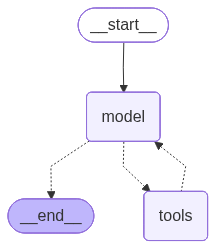

In [33]:
from langchain_core.messages import HumanMessage
from langchain.agents import create_agent
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

financial_analyst = create_agent(model=llm,
                                    tools=tools,
                                    system_prompt=SYS_PROMPT)
financial_analyst

## Test Financial Analyst ReAct Agent

In [24]:
from IPython.display import display, Markdown

for event in financial_analyst.stream(
    {"messages": [HumanMessage(content="Tell me some stocks I could potentially invest in")]},
    stream_mode='values' #returns full agent state with all messages including updates
):
    event["messages"][-1].pretty_print()

print('\n\nFinal Response:\n')
mssg_type=event["messages"][-1].content[0]['type']
mssg_content=event["messages"][-1].content[0][mssg_type]
display(Markdown(mssg_content))

================================ Human Message =================================

Tell me some stocks I could potentially invest in
================================== Ai Message ==================================
Tool Calls:
  get_general_market_data (027fea75-66fc-4193-87ac-78abb14f87ab)
 Call ID: 027fea75-66fc-4193-87ac-78abb14f87ab
  Args:
================================= Tool Message =================================
Name: get_general_market_data

Here's some detailed information of the stock market which includes most actively traded stocks, gainers and losers:

Most actively traded stocks:

|    | symbol   | name                          |   price |     change |   percent_change |    volume |    open |     high |      low |   previous_close |     ma50 |     ma200 |   year_high |   year_low |   market_cap |   shares_outstanding |   book_value |   price_to_book |   eps_ttm |   eps_forward |   pe_forward |   dividend_yield | exchange   | exchange_timezone   | earnings_date         

Here's some general market data that might help you identify potential investment opportunities. Please remember to conduct your own thorough research before making any investment decisions.

**Most Actively Traded Stocks (by Volume):**

*   **NVIDIA Corporation (NVDA)**: Price \$188.12, Change -0.73, Percent Change -0.39%
*   **Intel Corporation (INTC)**: Price \$39.37, Change -0.01, Percent Change -0.03%
*   **SoFi Technologies, Inc. (SOFI)**: Price \$29.28, Change 1.82, Percent Change 6.63%
*   **BigBear.ai, Inc. (BBAI)**: Price \$5.88, Change 0.04, Percent Change 0.68%
*   **Nu Holdings Ltd. (NU)**: Price \$17.94, Change 0.92, Percent Change 5.41%

**Top Price Gainers:**

*   **Figure Technology Solutions, In (FIGR)**: Price \$53.22, Change 9.48, Percent Change 21.67%
*   **QXO, Inc. (QXO)**: Price \$23.30, Change 3.58, Percent Change 18.15%
*   **AeroVironment, Inc. (AVAV)**: Price \$297.41, Change 41.22, Percent Change 16.09%
*   **NuScale Power Corporation (SMR)**: Price \$18.78, Change 2.47, Percent Change 15.14%
*   **Oklo Inc. (OKLO)**: Price \$89.34, Change 11.54, Percent Change 14.83%

**Top Price Losers:**

*   **United Parks & Resorts Inc. (PRKS)**: Price \$35.18, Change -1.04, Percent Change -2.87%
*   **Roivant Sciences Ltd. (ROIV)**: Price \$21.30, Change -0.63, Percent Change -2.87%
*   **Super Micro Computer, Inc. (SMCI)**: Price \$30.07, Change -0.89, Percent Change -2.87%
*   **Nuvalent, Inc. (NUVL)**: Price \$97.94, Change -2.90, Percent Change -2.88%
*   **Kenvue Inc. (KVUE)**: Price \$16.82, Change -0.50, Percent Change -2.89%

This data reflects recent market activity and can be a starting point for further investigation.

In [25]:
for event in financial_analyst.stream(
    {"messages": [HumanMessage(content="Tell me how is Nvidia doing right now as a company and could I potentially invest in it?")]},
    stream_mode='values' #returns full agent state with all messages including updates
):
    event["messages"][-1].pretty_print()

print('\n\nFinal Response:\n')
mssg_type=event["messages"][-1].content[0]['type']
mssg_content=event["messages"][-1].content[0][mssg_type]
display(Markdown(mssg_content))

================================ Human Message =================================

Tell me how is Nvidia doing right now as a company and could I potentially invest in it?
================================== Ai Message ==================================
Tool Calls:
  get_stock_ticker_symbol (09a67a41-4ccd-4df4-ae2b-ff5429c8d79d)
 Call ID: 09a67a41-4ccd-4df4-ae2b-ff5429c8d79d
  Args:
    stock_name: Nvidia
================================= Tool Message =================================
Name: get_stock_ticker_symbol

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name        |     cik |
|---:|:---------|:------------|--------:|
|  0 | NVDA     | NVIDIA CORP | 1045810 |
================================== Ai Message ==================================
Tool Calls:
  get_stock_price_metrics (a5fe1582-fc34-4a79-a914-081abc692d36)
 Call ID: a5fe1582-fc34-4a79-a914-081abc692d36
  Args:
    stock_ticker: NVDA
  get_stock_fundamental_indicator_metrics (6be621ea-c

Nvidia (symbol: NVDA) is currently trading at approximately \$187.99. The stock has seen a slight decrease of about 0.39% today and 1.26% over the last week. However, its performance over longer periods has been significantly positive, with a 4.75% increase in the last month, 0.87% year-to-date, and an impressive 40.08% over the past year. Looking at a broader historical context, Nvidia's stock has shown exceptional growth with returns of 1240.27% over 3 years, 1358.29% over 5 years, and 22585.56% over 10 years.

From a fundamental perspective, Nvidia demonstrates strong financial health. It has a gross profit margin of approximately 70.05% and a net profit margin of about 53.01%. The company's debt-to-equity ratio is low at around 8.82%. The Price-to-Earnings (P/E) ratio is currently 46.13, with a forward P/E of 24.86, and a PEG ratio of 0.72, which can sometimes indicate potential for future growth when below 1.

Recent news indicates ongoing developments and investor interest in Nvidia, particularly concerning its role in Artificial Intelligence (AI). Headlines mention Nvidia's partnerships in autonomous driving models and the CEO confirming the Vera Rubin AI platform is in full production. There are also discussions about whether AI stocks, including Nvidia, still offer significant investment opportunities, with some articles suggesting a potential AI "bubble" but not yet sounding alarms.

Regarding your interest in potentially investing in Nvidia, it's important to consider that while the company shows strong financial indicators and significant historical growth, past performance is not indicative of future results. The decision to invest should align with your individual financial goals, risk tolerance, and a comprehensive personal research. I recommend consulting with a financial advisor to make informed investment decisions.

In [26]:
def call_financial_analyst_agent(query, verbose=False):

    for event in financial_analyst.stream(
        {"messages": [HumanMessage(content=query)]},
        stream_mode='values' #returns full agent state with all messages including updates
    ):
        if verbose:
            event["messages"][-1].pretty_print()

    print('\n\nFinal Response:\n')
    mssg_type=event["messages"][-1].content[0]['type']
    mssg_content=event["messages"][-1].content[0][mssg_type]
    display(Markdown(mssg_content))

In [27]:
call_financial_analyst_agent(query="Do a comparative analysis between Nvidia and Intel and recommend which one to buy or avoid?",
                             verbose=True)

================================ Human Message =================================

Do a comparative analysis between Nvidia and Intel and recommend which one to buy or avoid?
================================== Ai Message ==================================
Tool Calls:
  get_stock_ticker_symbol (0eab8895-5bec-4b4f-8cdf-b14f12283891)
 Call ID: 0eab8895-5bec-4b4f-8cdf-b14f12283891
  Args:
    stock_name: Nvidia
  get_stock_ticker_symbol (55acb4be-18ce-4e6f-8d4e-bf3e791eb1c5)
 Call ID: 55acb4be-18ce-4e6f-8d4e-bf3e791eb1c5
  Args:
    stock_name: Intel
================================= Tool Message =================================
Name: get_stock_ticker_symbol

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name                                                           |     cik |
|---:|:---------|:---------------------------------------------------------------|--------:|
|  0 | INTC     | INTEL CORP                                                     |  

Here's a comparative analysis between Nvidia (NVDA) and Intel (INTC), along with a recommendation based on the current market data:

### **Nvidia (NVDA) - NVIDIA CORP**

**Current Stock Price:** \$187.99
**Price Performance (as of 2026-01-05):**
*   **1-Day:** -0.39%
*   **1-Week:** -1.26%
*   **1-Month:** +4.75%
*   **3-Month:** +0.27%
*   **6-Month:** +18.88%
*   **Year-to-Date (YTD):** +0.87%
*   **1-Year:** +40.08%
*   **3-Year:** +1240.27%
*   **5-Year:** +1358.29%
*   **10-Year:** +22585.56%

**Key Fundamental Ratios (Trailing Twelve Months - TTM as of 2026-01-06):**
*   **Price to Earnings (PE) Ratio:** 46.13
*   **Forward PE:** 24.86
*   **PEG Ratio (TTM):** 0.72
*   **Price to Book:** 38.49
*   **Price to Sales:** 24.47
*   **Gross Profit Margin:** 70.05%
*   **Net Profit Margin:** 53.01%
*   **Return on Assets:** 53.53%
*   **Return on Equity:** 107.36%
*   **Earnings Growth:** 66.7%
*   **Revenue Growth:** 62.5%
*   **Debt to Equity:** 0.088

**Recent News Highlights:**
Nvidia continues to be a central player in the AI landscape, with recent news focusing on its advancements in AI, autonomous car AI models (like Alpamayo), and discussions around its "AI moat." The company's stock has seen a significant rally, raising questions about potential threats to its growth in 2026.

### **Intel (INTC) - INTEL CORP**

**Current Stock Price:** \$39.4392
**Price Performance (as of 2026-01-05):**
*   **1-Day:** -0.03%
*   **1-Week:** +8.76%
*   **1-Month:** -10.03%
*   **3-Month:** +6.90%
*   **6-Month:** +78.95%
*   **Year-to-Date (YTD):** +6.69%
*   **1-Year:** +96.36%
*   **3-Year:** +54.15%
*   **5-Year:** -16.36%
*   **10-Year:** +12.55%

**Key Fundamental Ratios (Trailing Twelve Months - TTM as of 2026-01-06):**
*   **Price to Earnings (PE) Ratio:** 897.56
*   **Forward PE:** 66.11
*   **Price to Book:** 1.67
*   **Price to Sales:** 3.24
*   **Gross Profit Margin:** 35.77%
*   **Net Profit Margin:** 0.37%
*   **Return on Assets:** -0.46%
*   **Return on Equity:** 0.19%
*   **Earnings Growth:** Approximately 0%
*   **Revenue Growth:** 2.8%
*   **Debt to Equity:** 0.438

**Recent News Highlights:**
Intel shares saw a jump ahead of CES, with its Panther Lake chips in the spotlight. There's optimism from some analysts regarding an "AI upgrade" for Intel stock, and the company recently launched its next-gen PC chip. However, there are also discussions about the semiconductor rally fading.

### **Comparative Analysis and Recommendation**

**Performance:**
Nvidia has demonstrated exceptionally strong long-term growth, with its stock price soaring over the past 3, 5, and 10 years. In contrast, while Intel has shown some positive short-term performance, its 5-year return is negative, and its 10-year return is significantly lower than Nvidia's.

**Profitability and Growth:**
Nvidia's profitability margins (gross and net) are vastly superior to Intel's, indicating much more efficient operations and higher returns on sales. Nvidia also boasts impressive earnings and revenue growth rates, reflecting its dominant position in high-growth segments. Intel's profitability is very low, and its earnings growth is almost flat, with modest revenue growth.

**Valuation:**
Nvidia's valuation ratios (P/E, P/B, P/S) are high, but its PEG ratio of 0.72 suggests that its price is reasonable when considering its rapid earnings growth. Intel, on the other hand, has an exceptionally high P/E ratio, indicating that its stock might be significantly overvalued relative to its current earnings, especially given its low profitability and growth.

**Market Position and Innovation:**
Nvidia is a clear leader in the booming AI and accelerated computing markets, continuously innovating with new technologies for autonomous vehicles and data centers. While Intel is making efforts in AI and launching new chips, it faces intense competition and is in a different phase of its growth cycle.

**Recommendation:**

Based on this comparative analysis, **Nvidia (NVDA)** appears to be a more compelling investment due to its robust financial performance, strong growth trajectory, and leadership in high-demand technological sectors. Its higher valuation is largely supported by its exceptional growth and profitability.

Conversely, **Intel (INTC)** shows weaker fundamentals, significantly lower profitability, and a very high Price to Earnings ratio relative to its growth, making it a less attractive option at this time.

Therefore, for investors seeking growth and strong financial performance, you might **consider buying Nvidia (NVDA)** and **avoiding Intel (INTC)**, at least until Intel demonstrates more consistent and significant improvements in its financial fundamentals.

***

**Disclaimer:** This information is for educational purposes only and should not be considered financial advice. Investing in the stock market involves risks, and you should always conduct your own thorough research and consult with a qualified financial advisor before making any investment decisions.

In [30]:
call_financial_analyst_agent(query="Is Intel having any issues of late, could it still be a good buy?",
                    verbose=True)

================================ Human Message =================================

Is Intel having any issues of late, could it still be a good buy?
================================== Ai Message ==================================
Tool Calls:
  get_stock_ticker_symbol (202ecad5-7c4a-4697-8fd7-9387b46ced48)
 Call ID: 202ecad5-7c4a-4697-8fd7-9387b46ced48
  Args:
    stock_name: Intel
================================= Tool Message =================================
Name: get_stock_ticker_symbol

Here are the details of the company and its stock ticker symbol:

|    | symbol   | name                                                           |     cik |
|---:|:---------|:---------------------------------------------------------------|--------:|
|  0 | INTC     | INTEL CORP                                                     |   50863 |
|  1 | ZK       | ZEEKR Intelligent Technology Holding Ltd                       | 1954042 |
|  2 | CCC      | CCC Intelligent Solutions Holdings Inc.          

Intel (symbol: INTC) has been a subject of recent market interest, with news headlines from January 5, 2026, indicating positive developments such as Intel shares jumping ahead of CES, an AI upgrade for Intel stock, and the launch of next-gen PC chips. However, one headline also noted that the stock initially surged but gave up most of its gains.

Here's a look at Intel's recent performance and fundamental indicators:

**Current Price and Performance (as of January 5, 2026):**
*   **Last Price:** \$39.4392
*   **Daily Change:** -\$0.01 (-0.000254%)
*   **One Week Performance:** +8.76%
*   **One Month Performance:** -10.03%
*   **Six Month Performance:** +78.95%
*   **One Year Performance:** +96.36%
*   **Year High:** \$44.02
*   **Year Low:** \$17.67

**Fundamental Indicators:**
*   **Price-to-Earnings (PE) Ratio:** 656.167 (This is very high and could suggest the stock is overvalued.)
*   **Forward Price-to-Earnings (Forward PE):** 66.1136 (While still high, it's significantly lower than the current PE, indicating expectations of substantial future earnings growth.)
*   **Net Profit Margin:** 0.00371 (This is quite low, suggesting limited profitability relative to revenue.)
*   **Return on Assets (ROA):** -0.00463 (A negative ROA indicates that the company is not efficiently using its assets to generate profits.)
*   **Return on Equity (ROE):** 0.00186 (This is very low, implying a low return for shareholders' investments.)
*   **Debt to Equity:** 39.881 (This is a relatively high ratio, which could be a point of concern regarding the company's financial leverage.)

**Is it still a good buy?**

Intel has shown strong price appreciation over the past year and six months, fueled by positive news surrounding AI and new product innovations. The significant difference between its current and forward PE ratios suggests that the market anticipates considerable future growth.

However, investors should be aware of several challenges: the extremely high current PE ratio, very thin profit margins, negative return on assets, and a high debt-to-equity ratio. These fundamental metrics suggest that, despite the positive sentiment and recent price gains, the company faces profitability and efficiency issues.

While the recent news and market momentum are positive, the underlying financial health shows some areas of concern. It is crucial for investors to conduct their own thorough research and consider these factors in light of their investment goals and risk tolerance before making any investment decisions.

In [29]:
call_financial_analyst_agent(query="Give me the Market Cap, PE Ratio, Revenue per share for Microsoft",
                             verbose=False)



Final Response:



Here is the requested information for Microsoft (symbol: MSFT):

*   **Market Cap**: \$3,514,772,750,336
*   **PE Ratio**: 33.68
*   **Revenue per share**: \$39.53

In [ ]:
call_financial_analyst_agent(query="Do a price analysis for Apple and give me some insights from it",
                             verbose=False)